## Setup

### Import Libraries

In [10]:
import copy

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.datasets import make_blobs

from ipywidgets import interact, IntSlider
import owncloud
import xarray as xr

### Utility Functions

In [4]:
def train(model: nn.Module, features: torch.Tensor, labels: torch.Tensor, optimizer: torch.optim.Optimizer, loss_function = nn.CrossEntropyLoss()) -> None:
    optimizer.zero_grad()
    output = model.forward(features)
    loss = loss_function(output, labels)
    loss.backward()
    optimizer.step()

def calculate_accuracy(model: nn.Module, features: torch.Tensor, labels: torch.Tensor, verbose = True) -> torch.Tensor: 

    output = model(features)
    accuracy = (labels == torch.argmax(output, dim=1)).sum()/len(labels)
    if verbose:
        print(f'Accuracy: {(accuracy*100).item()}')
    return (accuracy*100).item()

def do_binary_classification_interactive(model, X, labels, nepochs=40, step_size = 1, optimizer_class = optim.RMSprop):
    """Interactive binary classification with epoch slider"""

    loss_function=nn.BCEWithLogitsLoss()

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(epoch_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))
        optimizer = optimizer_class(model.parameters(), lr=0.1)

        # Train up to the selected epoch
        for epoch in range(epoch_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_function(y_pred.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

        # Plot the result at this epoch
        with torch.no_grad():
            y_pred = model(X)
            probs = torch.sigmoid(y_pred)

        plt.figure(figsize=(6, 5))
        plt.title(f"epoch={epoch_to_show}, loss={loss.item():.4f}")
        plt.scatter(*X.T, s=20, c=(probs > 0.5).squeeze(), cmap='Set1')
        plt.show()

    # Create slider
    epoch_slider = IntSlider(min=0, max=nepochs, step=step_size, value=0, description='Epoch:')
    interact(train_and_plot, epoch_to_show=epoch_slider)

class utils:
    train = train
    calculate_accuracy = calculate_accuracy
    do_binary_classification_interactive = do_binary_classification_interactive


### Download Data

In [5]:
Path('data').mkdir(exist_ok=True, parents=True)

owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/3Uf2gScrvuTPQhB').get_file('/', f'data/steinmetz_2017-01-08_Muller.nc')

True

Extract data needed to train a classifier that can identify stimulus type (left contrast, right contrast, equal contrast) from spikes

In [6]:
dset = xr.load_dataset('data/steinmetz_2017-01-08_Muller.nc')
dset

<xarray.Dataset> Size: 124MB
Dimensions:             (trial: 261, time: 250, cell: 1268, sample: 82,
                         waveform_component: 3, probe: 384, brain_area_lfp: 5,
                         spike_id: 1836009)
Coordinates:
  * trial               (trial) int32 1kB 1 2 3 4 5 6 ... 257 258 259 260 261
  * time                (time) float64 2kB 0.01 0.02 0.03 0.04 ... 2.48 2.49 2.5
  * cell                (cell) int32 5kB 1 2 3 4 5 ... 1264 1265 1266 1267 1268
  * waveform_component  (waveform_component) int32 12B 1 2 3
  * probe               (probe) int32 2kB 1 2 3 4 5 6 ... 380 381 382 383 384
  * brain_area_lfp      (brain_area_lfp) <U5 100B 'CA1' 'DG' 'LP' 'PO' 'VISam'
  * spike_id            (spike_id) int32 7MB 1 2 3 4 ... 1836007 1836008 1836009
Dimensions without coordinates: sample
Data variables: (12/31)
    contrast_left       (trial) int8 261B 50 0 100 0 50 0 ... 100 0 100 0 100 0
    contrast_right      (trial) int8 261B 0 50 25 100 50 50 ... 100 50 100 25 25
    gocue               (trial) float64 2kB 0.9828 0.902 1.114 ... nan nan nan
    stim_onset          (trial) float64 2kB 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    feedback_type       (trial) float64 2kB 1.0 1.0 1.0 1.0 ... nan nan nan nan
    feedback_time       (trial) float64 2kB 1.272 1.104 1.402 ... nan nan nan
    ...                  ...
    waveform_w          (cell, sample, waveform_component) float32 1MB 0.0 .....
    waveform_u          (cell, waveform_component, probe) float32 6MB 0.0 ......
    lfp                 (brain_area_lfp, trial, time) float64 3MB -27.6 ... 0...
    spike_time          (spike_id) float32 7MB 2.363 2.385 ... 1.651 0.5142
    spike_cell          (spike_id) uint32 7MB 1 1 1 1 1 ... 1268 1268 1268 1268
    spike_trial         (spike_id) uint32 7MB 1 1 2 2 2 ... 205 205 205 213 252
Attributes:
    session_date:  2017-01-08
    mouse:         Muller
    stim_onset:    0.5
    bin_size:      0.01

In [7]:
spike_cols = ['spike_time', 'spike_cell', 'spike_trial']
df_spikes = dset[spike_cols].to_dataframe().reset_index()

trial_ids = np.sort(df_spikes['spike_trial'].unique())
n_cells = dset.sizes['cell']

# features: spike counts per cell for each trial
features_trials = []
# labels: which side had higher contrast (0=left, 1=equal, 2=right)
labels_trials = []

for trial_id in trial_ids:
    # count spikes per cell
    counts = df_spikes[df_spikes['spike_trial'] == trial_id].groupby('spike_cell').size()
    feature_vector = np.zeros(n_cells)
    feature_vector[counts.index - 1] = counts.values
    features_trials.append(feature_vector)
    
    # create labels
    left = dset['contrast_left'].values[trial_id - 1]
    right = dset['contrast_right'].values[trial_id - 1]
    labels_trials.append(0 if left > right else 2 if right > left else 1)

features = torch.tensor(features_trials, dtype=torch.float32)
labels = torch.tensor(labels_trials, dtype=torch.long)


C:\Users\delgr\AppData\Local\Temp\ipykernel_25004\3749070799.py:24: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\bld\libtorch_1753839225953\work\torch\csrc\utils\tensor_new.cpp:257.)
  features = torch.tensor(features_trials, dtype=torch.float32)


## Section 1: Activation Functions Enables Neural Networks to Capture Non-Linear Relationships in Data

Often, the relationship you want to uncover in your data isn't linear. In this section, we'll see how to make neural network models that can capture non-linear patterns in the data.

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer of nodes (neurons) that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.ReLU()` | Creates a rectified linear unit (ReLU) activation function.|
| `nn.Tanh()` | Creates hyperbolic tangent activation function.|
| `nn.Sigmoid()` | Creates a sigmoid activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|
| `utils.do_binary_classification(model, X, labels)` | Do binary classification. `X` is the input data and `labels` are the true class labels for the data. |
| `utils.do_binary_classification(model, X, labels, epochs=200)` | Do binary classification and set the number of epochs to 200. |

Run cell below to generate data for **linear** binary classification

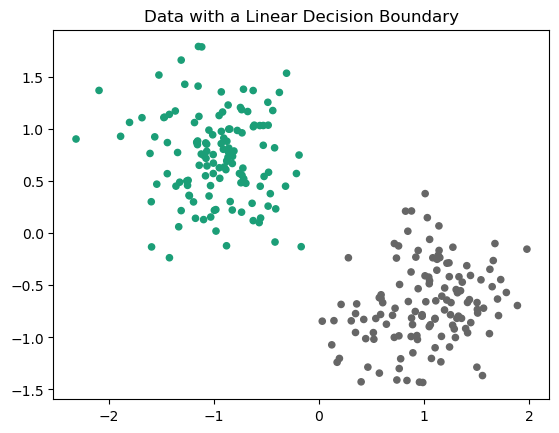

In [8]:
# generate two linearly separable clusters
features_linear, labels_linear = make_blobs(
    n_samples=256, 
    centers=[[-1, 0.7], [1, -0.7]],
    cluster_std=0.4,
    random_state=2026
)
features_linear = torch.tensor(features_linear, dtype=torch.float32)
labels_linear = torch.tensor(labels_linear, dtype=torch.long)

plt.scatter(*features_linear.T, s=20, c=labels_linear, cmap='Dark2');
plt.title('Data with a Linear Decision Boundary');

**Exercise**: Run the cell below to create a linear model with 2 input features and 1 output feature and pass this model as input to the function `utils.do_binary_classification_interactive`. Drag the slider to train the model. Is this model able to classify points in the two clusters correctly after training?

In [11]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features_linear, labels_linear)

interactive(children=(IntSlider(value=0, description='Epoch:', max=40), Output()), _dom_classes=('widget-inter…

Run cell below to generate data for **non-linear** binary classification

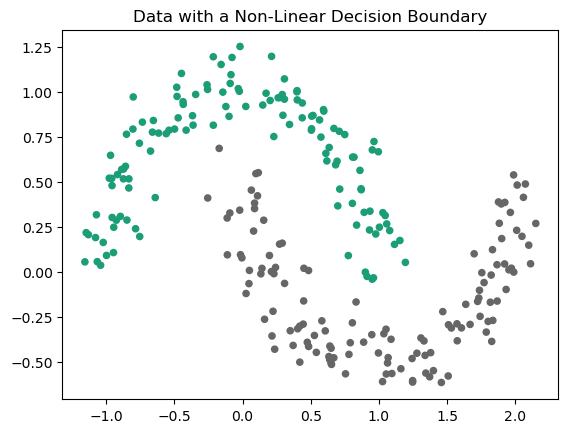

In [12]:
features_orig, labels_orig = make_moons(256, noise=0.1, random_state=42)
features = torch.tensor(features_orig, dtype=torch.float32)
labels = torch.tensor(labels_orig, dtype=torch.long)

plt.scatter(*features.T, s = 20, c = labels, cmap='Dark2')
plt.title('Data with a Non-Linear Decision Boundary');

**Exercise**: Create a linear model with 2 input features and 1 output feature. Pass this model as input to the function `utils.do_binary_classification`. Is this model able to classify points in the two clusters (mostly) correctly after training?

In [ ]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features, labels)

interactive(children=(IntSlider(value=0, description='Epoch:', max=40), Output()), _dom_classes=('widget-inter…

**Exercise**: Use the same model to do binary classification but this time, try increasing the number of epochs (no need to go beyond 200). Is the model able to do the classification correctly now?

In [14]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features, labels, nepochs=200)

interactive(children=(IntSlider(value=0, description='Epoch:', max=200), Output()), _dom_classes=('widget-inte…

Even if the result might have improved a little bit, the linear model isn't able to correctly classify all points, no matter how many epochs we train the model for. The reason for this is that the boundary separating the two classes of points is *non-linear*, and a linear model will never be able to capture a non-linear boundary. 

Models will only be able to solve non-linear problems if we add non-linearity to the model. Activation functions provide such non-linearity, and they are one of the key features that make neural networks so powerful.

**Demo**: Run the cell below to create a model composed of two layers with a rectified linear unit (ReLU) activation function between them and pass the model to the utility function `utils.do_binary_classification_interactive`. Drag the slider to train the model. Is the model able to correctly classify all the points now?

In [15]:
torch.manual_seed(2026)
# create model
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

utils.do_binary_classification_interactive(model, features, labels, nepochs=100)

interactive(children=(IntSlider(value=0, description='Epoch:'), Output()), _dom_classes=('widget-interact',))

## Section 3: Classify Stimulus Information from Neural Spike Data

In the previous sections, we saw how neural networks can capture non-linear decision boundaries using synthetic data. Now let's apply the same approach to real neuroscience data. We'll train a classifier to classify which visual stimulus was presented to a mouse based on the activity of neurons recorded during the experiment. The task is to predict whether the left stimulus had higher contrast, the right stimulus had higher contrast, or both had equal contrast. This is a three-class classification problem.

| Code | Description |
| :-- | :-- |
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(n_features, 64),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(64, 3)`<br>`)` | Creates a neural network with one hidden layer (64 nodes) and ReLU activation for 3-class classification. |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function for multiclass classification. |
| `torch.optim.SGD(model.parameters(), lr=0.001)` | Creates a stochastic gradient descent optimizer with a learning rate of 0.001. |
| `losses = []` | Initialize an empty list to stores the loss values. |
| `losses.append(loss.item())` | Stores the loss value in a list. |
| `utils.calculate_accuracy(model, features, labels)` | Calculates the accuracy of the model on the given data. |

The features and labels that the model will be trained have already been extracted from the dataset. 

The labels are class labels - they tell you which stimulus class was presented in a trial. Label 0: contrast left, label 1: contrast is equal, label 2: contrast right. These make out the targets that the model predictions are compared to to assess how well the model is performing. There are 261 labels, one for each trial.

The features are the spike counts of each (real biological) cell in each trial. There are 1268 cells and in the dataset, which means that there are 1268 features for the model to train on and use to make its prediction about the stimulus type presented in a given trial.

Run the cell below to take a look at the dimensions of data and the content of `labels`.

Softmax is often used to express the output of a model in probabilities. When a model does multiclass classification, that probability expresses the model's confidence that something belongs to one class or the other.

In [120]:
print(f'Number of trials: {features.shape[0]}')
print(f'Number of cells: {features.shape[1]}')
print(f'len(labels): {len(labels)}')
print(f'labels: {labels}')

Number of trials: 261
Number of cells: 1268
len(labels): 261
labels: tensor([0, 2, 0, 2, 1, 2, 2, 0, 1, 0, 0, 2, 2, 2, 0, 0, 1, 1, 2, 0, 0, 1, 1, 0,
        0, 0, 2, 0, 2, 0, 1, 2, 2, 1, 0, 0, 1, 1, 1, 0, 0, 2, 0, 1, 0, 2, 2, 1,
        1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 0,
        0, 0, 1, 1, 1, 2, 2, 0, 0, 1, 2, 2, 0, 2, 1, 1, 1, 2, 0, 2, 1, 1, 0, 0,
        2, 0, 2, 2, 2, 2, 1, 2, 1, 1, 0, 2, 1, 2, 0, 1, 1, 0, 2, 0, 2, 1, 2, 2,
        0, 0, 2, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 2, 1, 1, 2, 2, 2, 2, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 0, 2, 2, 2, 0, 2, 0, 2, 2, 2,
        0, 0, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2,
        0, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 0, 2,
        2, 2, 1, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2,
        1, 2, 0, 2, 0, 1, 0, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2])


**Exercise**: Create a neural network model with one hidden layer and a ReLU activation function. The number of input nodes should match the number of features in the dataset (1268), the hidden layer should have 64 neurons, and the output layer should have 3 nodes (one per stimulus class). The ReLU activation function should come directly after the hidden layer. Assign the model to a variable named `model` and display it.

In [122]:
n_features = 1268

In [125]:
torch.manual_seed(2026)
model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)
model

Sequential(
  (0): Linear(in_features=1268, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=3, bias=True)
)

**Exercise**: For the model created below, set up an gradient descent (SGD) optimizer with learning rate `lr = 0.01`. 

In [126]:
torch.manual_seed(2026)
model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)
model

Sequential(
  (0): Linear(in_features=1268, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=3, bias=True)
)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

**Exercise**: Create a cross-entropy loss function (the loss function appropriate for multiclass classification problems) and assign it to a variable `loss_fn`.

In [ ]:
loss_fn = nn.CrossEntropyLoss()

**Example**: Let's see how well the model performs before training. Run the cell below to create the model and make a prediction by passing the features to the model and calculate the loss. Then, calculate the accuracy using the utility function `utils.calculate_accuracy` and print the loss and the accuracy.

In [168]:
# create model
torch.manual_seed(2026)
model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)

# create optimizer for model 
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# create loss function
loss_fn = nn.CrossEntropyLoss()

# pass the input to the model and get a prediction
model_pred = model(features)

# calculate the loss
loss = loss_fn(model_pred, labels)

In [169]:
accuracy = utils.calculate_accuracy(model, features, labels, verbose=False)
print(f"Epoch {0}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

Epoch 0, Loss: 1.9130, Accuracy: 22.9885


**Exercise**: Run the cell below to train the model for one epoch. Then, calculate the accuracy using the utility function `utils.calculate_accuracy` and print the loss and the accuracy.

In [170]:
for epoch in range(1):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    model_pred = model(features)

    # calculate the loss
    loss = loss_fn(model_pred, labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

In [171]:
accuracy = utils.calculate_accuracy(model, features, labels, verbose=False)
print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

Epoch 0, Loss: 1.9130, Accuracy: 40.6130


**Exercise**: Run the cell below to train the model for 10 epochs. Then, calculate the accuracy using the utility function `utils.calculate_accuracy` and print the loss and the accuracy.

In [172]:
for epoch in range(10):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    model_pred = model(features)

    # calculate the loss
    loss = loss_fn(model_pred, labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

In [173]:
accuracy = utils.calculate_accuracy(model, features, labels, verbose=False)
print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

Epoch 9, Loss: 0.9766, Accuracy: 54.0230


**Example**: Add a line to store the loss in each epoch in a variable named `losses`. Then, run the first cell to train the model over 20 epochs and the second cell to visualize the loss over epochs.

In [184]:
# create model
torch.manual_seed(2026)
model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)

# create optimizer for model 
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

losses = []
for epoch in range(20):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    model_pred = model(features)

    # calculate the loss
    loss = loss_fn(model_pred, labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    # store loss in this epoch
    losses.append(loss.item())

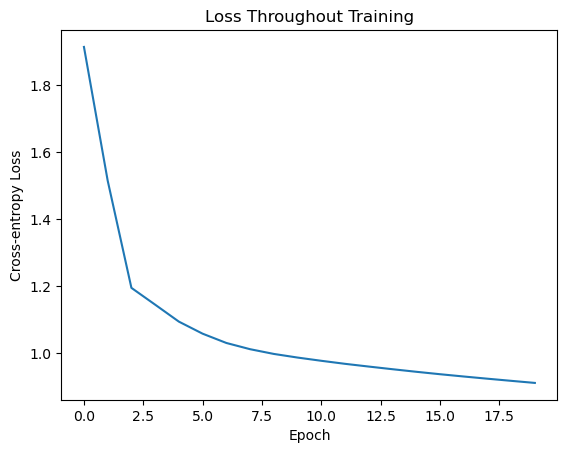

In [185]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy Loss')
plt.title('Loss Throughout Training');

**Exercise**: Add a line to store the loss in each epoch in a variable named `losses`. Then, run the first cell to train the model over 100 epochs and the second cell to visualize the loss over epochs.

In [ ]:
# create model
torch.manual_seed(2026)
model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)

# create optimizer for model 
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


___ # initialize list to store loss
for epoch in range(100):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    model_pred = model(features)

    # calculate the loss
    loss = loss_fn(model_pred, labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()

    
    ___ # store loss in this epoch

In [179]:
# create model
torch.manual_seed(2026)
model = nn.Sequential(
    nn.Linear(n_features, 64),
    nn.ReLU(),
    nn.Linear(64, 3)
)

# create optimizer for model 
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


losses = [] # initialize list to store loss
for epoch in range(100):
    # reset the gradients
    optimizer.zero_grad()

    # pass the input to the model
    model_pred = model(features)

    # calculate the loss
    loss = loss_fn(model_pred, labels)

    # perform backward propagation to calculate the gradients
    loss.backward()

    # update the parameters
    optimizer.step()
    
    losses.append(loss.item()) # store loss in this epoch

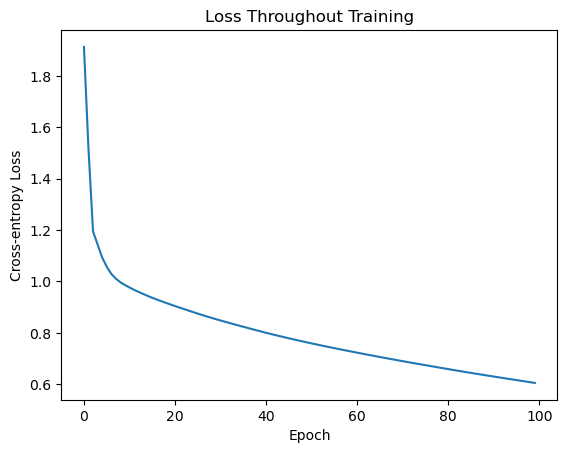

In [180]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy Loss')
plt.title('Loss Throughout Training');

**Exercise**: Calculate the accuracy of the model trained above using `utils.calculate_accuracy`.

In [181]:
accuracy = utils.calculate_accuracy(model, features, labels, verbose=False)
print(f"Epoch {epoch}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

Epoch 99, Loss: 0.6052, Accuracy: 78.9272


The model achieves over 78% accuracy on the training data. But does this mean it has truly learned to decode neural activity, or has it simply memorized the training examples? To answer this question, we need to evaluate the model on data it has never seen before. We'll learn how to do this properly on Day 2 when we cover train/test splitting and overfitting.

## Section 5: Understanding The Classification Accuracy Equation

The output of the network is a score for each class that reflects the networks belief that a data point corresponds to a given class. This is not the same as a class label. To get the output in the form of a class guess by the network, we have to determine which class the network thinks that a data point is most likely to belong to using the output scores. In the previous sections, you used a utility function to do this. Here, you'll learn how to do it yourselves.

| Code | Description |
| --- | --- |
| `torch.argmax(x, dim=1)` | Finds the index at which the **tensor** `x` has the highest value along its dimension 1. |
| `a == b` | Compares each element of the tensors (or arrays) `a` and `b` and returns a tensor of boolean (`True` or `False`) values indicating which elements are the same (`True`) and different (`False`). |
| `(a == b).sum()` or `torch.sum(a == b)`| Sums all elements where the condition `a == b` is `True`. `True` is counted as 1, `False` as 0. |
| `(a == b).sum() / len(a)` | Calculates proportion of elements in `a` where the element is equal to the corresponding element in `b`.|

**Example**: Run the cell below to get the model's raw output scores for the spike data. The output has shape `(261, 3)` - one row per trial, with 3 scores (one per stimulus class). Use `torch.argmax` to find which class has the highest score for each trial.

In [186]:
# Get model predictions
with torch.no_grad():
    output = model(features)

print(f'Output shape: {output.shape}')
print(f'First 5 rows of output:\n{output[:5]}')

Output shape: torch.Size([261, 3])
First 5 rows of output:
tensor([[1.7227, 0.3785, 1.5947],
        [1.9458, 0.9166, 1.3299],
        [1.1399, 0.8212, 2.0056],
        [1.7931, 1.0636, 1.7579],
        [2.0801, 1.0031, 2.6745]])


In [187]:
predicted_labels = torch.argmax(output, dim=1)
predicted_labels[:10]

tensor([0, 0, 2, 0, 2, 1, 2, 0, 1, 2])

**Exercise**: Compare the predicted labels to the true labels using `==`. The result is a tensor of boolean values (`True` where the prediction is correct, `False` where it is wrong).

In [188]:
predicted_labels == labels

tensor([ True, False, False, False, False, False,  True,  True,  True, False,
         True, False,  True,  True,  True,  True, False, False, False,  True,
        False,  True, False,  True,  True,  True, False,  True, False, False,
         True, False, False, False,  True, False,  True,  True,  True,  True,
         True, False,  True, False,  True, False,  True,  True, False,  True,
         True, False,  True, False,  True, False,  True, False,  True,  True,
         True,  True,  True,  True, False, False,  True,  True,  True,  True,
         True, False, False,  True,  True, False, False,  True,  True, False,
        False,  True, False,  True,  True, False, False,  True, False, False,
         True, False,  True,  True,  True, False, False,  True, False,  True,
         True,  True, False,  True,  True,  True,  True, False,  True,  True,
        False,  True,  True,  True,  True, False,  True, False,  True, False,
         True,  True,  True,  True, False, False, False,  True, 

**Exercise**: Use `.sum()` on the comparison result to count how many predictions are correct. (`True` counts as 1 and `False` counts as 0.)

In [189]:
(predicted_labels == labels).sum()

tensor(152)

**Exercise**: Calculate the accuracy by dividing the number of correct predictions by the total number of labels.

In [190]:
(predicted_labels == labels).sum() / len(labels)

tensor(0.5824)

**Exercise**: Multiply the accuracy by 100 to express it as a percentage. This is the accuracy.

In [191]:
(predicted_labels == labels).sum() / len(labels) * 100

tensor(58.2375)

In [ ]:
labels  # provided
predicted_labels = torch.argmax(output, dim=1)
(predicted_labels == labels).mean()

In [ ]:
classification_accuracy = (output.argmax(dim=1) == labels).mean()

## Section 4: Different Problems Require Different Kinds of Loss Functions

So far, we've used mean squared error (MSE) as our loss function. MSE works well for regression problems, where we're trying to predict a continuous value like a firing rate or a price. But not all machine learning problems are regression problems. In classification problems, we're trying to predict which category something belongs to - for example, whether an image shows a cat or a dog, or which type of stimulus was presented to the animal in an experiment. For these problems, MSE doesn't work well because we're not measuring distance from a target value, we're measuring how confident the model is in its class prediction. PyTorch provides different loss functions for different types of problems:

- **MSE Loss** (`nn.MSELoss()`): For regression - predicting continuous values
- **Binary Cross-Entropy** (`nn.BCEWithLogitsLoss()`): For binary classification - two classes
- **Cross-Entropy** (`nn.CrossEntropyLoss()`): For multiclass classification - more than two classes

In all cases, the loss measures how wrong the model's predictions are. Lower loss means better predictions, and training a neural network means finding parameters that minimize the loss.

| Code | Description |
| --- | --- |
| `nn.MSELoss()` | Creates a mean squared error (MSE) loss function. Used for regression problems. |
| `nn.BCEWithLogitsLoss()` | Creates a binary cross-entropy loss function. Used for binary classification (two classes). |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function. Used for multiclass classification (more than two classes). |
| `loss_function(y_pred, y_true)` | Calculates the loss between predictions `y_pred` and true values `y_true`. |
| `loss_function(y_pred, y_true).item()` | Extracts the loss value as a `float` from the tensor. |

**Example**: Create a binary cross-entropy loss function using PyTorch's `nn` module.

In [ ]:
nn.BCEWithLogitsLoss()

BCEWithLogitsLoss()

**Exercise**: Create a binary cross-entropy loss function using PyTorch's `nn` module and assign it to a variable named `loss_function`. Display the variable.

In [ ]:
loss_function = nn.BCEWithLogitsLoss()
loss_function

BCEWithLogitsLoss()

**Exercise**: Create a cross-entropy loss function for multiclass classification using PyTorch's `nn` module and assign it to a variable named `loss_function`. Display the variable.

In [ ]:
loss_function = nn.CrossEntropyLoss()
loss_function

CrossEntropyLoss()

Below we simulate a binary classification scenario. Imagine we have a model that predicts whether a neuron is "active" (1) or "inactive" (0) based on some input. The model outputs a raw score (called a "logit"). Positive values suggest "active", negative values suggest "inactive". Run the cell to print the output of the model (the raw score) and the true labels.

In [ ]:
# simulated model outputs (logits) for 4 samples
# Positive values = model thinks "active", negative = model thinks "inactive"
y_pred = torch.tensor([2.0, -1.0, 0.5, -2.0])

# True labels: 1 = active, 0 = inactive
y_true = torch.tensor([1.0, 0.0, 1.0, 0.0])

print(f"Model predictions (logits): {y_pred}")
print(f"True labels: {y_true}")

Model predictions (logits): tensor([ 2.0000, -1.0000,  0.5000, -2.0000])
True labels: tensor([1., 0., 1., 0.])


**Example**:  Calculate the binary cross-entropy loss for the model prediction above.

In [ ]:
# create the binary cross-entropy loss function
loss_fn = nn.BCEWithLogitsLoss()
# calculate binary cross-entropy loss
loss = loss_fn(y_pred, y_true)

print(f"Binary cross-entropy loss: {loss.item():.4f}")

Binary cross-entropy loss: 0.2603


**Exercise**: The cell below contains a different set of predictions for the same true labels. The model made worse predictions this time (the signs of the logits don't match the true labels as well). Calculate the binary cross-entropy loss. Is the loss higher or lower than in the example above?

In [ ]:
# bad predictions - signs often don't match true labels
y_pred = torch.tensor([-1.0, 1.0, -0.5, 1.0])

# True labels (same as before)
y_true = torch.tensor([1.0, 0.0, 1.0, 0.0])

In [ ]:
loss_bad = loss_fn(y_pred, y_true)
print(f"Binary cross-entropy loss: {loss_bad.item():.4f}")

# The loss is higher because the predictions are worse

Binary cross-entropy loss: 1.2285


Below, we simulate multiclass classification. For multiclass classification, the model outputs a score for each possible class. Our hypothetical model that classifies images into 3 categories indicating where the stimulus was presented: "stimulus left" (0), "stimulus middle" (1), or "stimulus right" (2). The model outputs 3 scores per sample - higher scores indicate higher confidence in that class.

In [ ]:
# model outputs for 3 samples, with 3 classes each (stimulus left, stimulus middle, stimulus right)
# each row is one sample, each column is the score for one class
y_pred = torch.tensor([
    [2.0, 0.5, -1.0],   # Sample 1: highest score for stimulus left (index 0)
    [-1.0, 2.5, 0.0],   # Sample 2: highest score for stimulus middle (index 1)
    [0.0, -0.5, 3.0]    # Sample 3: highest score for stimulus right (index 2)
])

# true labels (class indices): stimulus left=0, stimulus middle=1, stimulus right=2
y_true = torch.tensor([0, 1, 2])

print(f"Model predictions (logits):\n{y_pred}")
print(f"True labels: {y_true}")

Model predictions (logits):
tensor([[ 2.0000,  0.5000, -1.0000],
        [-1.0000,  2.5000,  0.0000],
        [ 0.0000, -0.5000,  3.0000]])
True labels: tensor([0, 1, 2])


In [ ]:
# calculate cross-entropy loss
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(y_pred, y_true)

print(f"Cross-entropy loss: {loss.item():.4f}")

Cross-entropy loss: 0.1416


**Exercise**: The cell below contains predictions where the model made some mistakes (the highest scores don't always match the true labels). Calculate the cross-entropy loss using the `loss_fn` defined above. Is the loss higher or lower than in the example?

In [ ]:
# bad predictions - highest scores don't match true labels
y_pred = torch.tensor([
    [0.5, 2.0, -1.0],   # Sample 1: highest score for stimulus middle, but true label is stimulus left
    [-1.0, 2.5, 0.0],   # Sample 2: highest score for stimulus middle (correct)
    [2.0, -0.5, 1.0]    # Sample 3: highest score for stimulus left, but true label is stimulus right
])

# True labels (same as before)
y_true = torch.tensor([0, 1, 2])

In [ ]:
loss_bad = loss_fn(y_pred, y_true)
print(f"Cross-entropy loss: {loss_bad.item():.4f}")

# The loss is higher because the predictions are worse

Cross-entropy loss: 1.0731
